In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re
import os
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import multilabel_confusion_matrix
from statistics import mean
import math
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import matthews_corrcoef
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

In [ ]:
!nvidia-smi  # Check GPU type
!cat /proc/meminfo | grep MemTotal  # Check total RAM


Thu Sep 25 11:24:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/Final FV/COMBINE FILE-FV/DATASET 1.csv')
x = df.sample(frac=1)
x.to_csv(('/content/drive/MyDrive/new.csv') , index=False)


In [ ]:
df

,FV1,FV2,FV3,FV4,FV5,FV6,FV7,FV8,FV9,FV10,...,FV513,FV514,FV515,FV516,FV517,FV518,FV519,FV520,FV521,CLASS-LABEL
0,9435,390011,21403639,1.322124e+09,388114,16089200,8.836494e+08,21059404,8.743913e+08,1.283313e+09,...,22238,23030,50479,58601,19065,44827,79167,68540,49574,0
1,7382,269056,12907222,6.947767e+08,262408,9636989,4.641328e+08,12306114,4.537181e+08,6.486750e+08,...,41690,28192,36238,53363,41552,31806,47496,24026,29215,0
2,12871,614235,38863801,2.766000e+09,612976,29255000,1.849606e+09,38602014,1.840405e+09,2.723398e+09,...,49066,22466,82149,74143,94185,147367,125748,74583,89820,0
3,13324,648284,41945426,3.050727e+09,655880,31797144,2.053901e+09,42577616,2.055764e+09,3.093700e+09,...,88021,65942,69451,115216,87660,115527,132444,61908,86592,0
4,8469,324438,16479440,9.419279e+08,323017,12380699,6.280145e+08,16494219,6.314446e+08,9.494133e+08,...,23949,5200,41667,96021,27451,71207,28045,28860,23865,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49036,326,2889,32787,4.179570e+05,2765,24065,2.700550e+05,31795,2.738050e+05,4.150130e+05,...,137,0,63,123,0,20,197,169,104,12
49037,307,2464,26108,3.151120e+05,2445,18894,1.978640e+05,24757,1.891440e+05,2.796690e+05,...,22,0,4,140,0,110,460,78,36,12
49038,980,16114,341026,8.058316e+06,14106,231269,4.880535e+06,272438,4.443689e+06,5.991174e+06,...,0,267,118,1528,40,369,1690,913,554,12
49039,2667,62303,1929959,6.715919e+07,59516,1384339,4.256264e+07,1764106,4.112920e+07,5.889945e+07,...,616,879,2686,4925,1225,4759,16804,8018,6835,12


In [ ]:
df1= pd.read_csv('/content/drive/MyDrive/new.csv')

In [ ]:
features= df1.drop(['CLASS-LABEL'], axis=1)
labels = df1['CLASS-LABEL']



**Label Encoder**

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
features = features.apply(le.fit_transform)

In [ ]:
import imblearn
from imblearn.over_sampling import SMOTE

smote = SMOTE()

features, labels = smote.fit_resample(features, labels)



In [ ]:
features.shape

(265902, 521)

**Standard Scaler For Features Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.get_params()
feature=scaler.fit_transform(features)

In [ ]:
feature.shape


(265902, 521)

In [ ]:
print(np.any(np.isinf(feature)))
print(np.any(np.isinf(labels)))


False
False


# **SELF CONSISTENCY TEST**

Self-Consistency Accuracy: 98.64%

Confusion Matrix:
 [[18835   511     0    12    12     0     3     2    13     0    33     0
   1033]
 [  557 18996     1     7    12     0     1     0    19     0    27     1
    833]
 [    0     0 20454     0     0     0     0     0     0     0     0     0
      0]
 [    1     1     0 20449     1     0     0     0     0     0     2     0
      0]
 [    3     2     0    10 20436     0     0     0     2     0     1     0
      0]
 [    0     0     0     0     0 20454     0     0     0     0     0     0
      0]
 [    0     0     0     0     0     0 20454     0     0     0     0     0
      0]
 [    0     0     0     0     0     0     0 20454     0     0     0     0
      0]
 [    0     0     0     0     0     0     0     0 20454     0     0     0
      0]
 [    0     0     0     0     0     0     0     0     1 20453     0     0
      0]
 [    0     1     0     3     0     0     1     0     3     0 20444     1
      1]
 [    0     0     0     0     0  

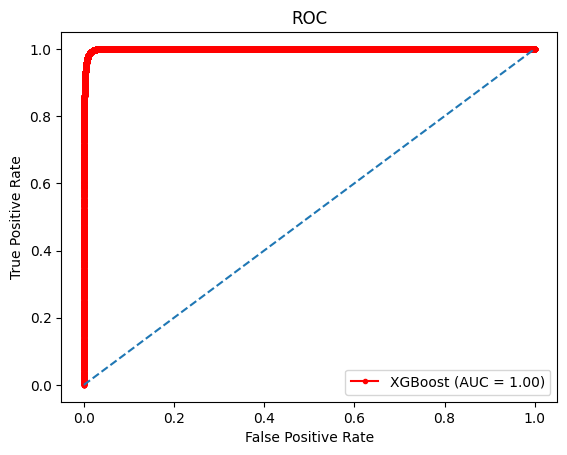

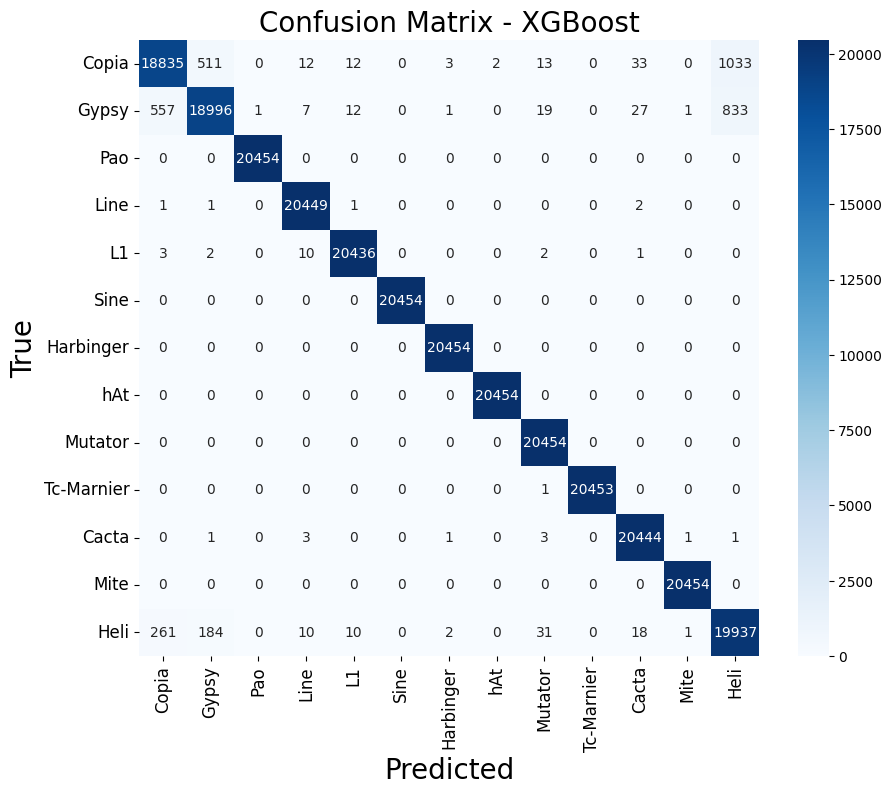

In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef

# ==============================
# Define optimized model
# ==============================
xgb_model = XGBClassifier(n_estimators=100)

# ==============================
# Train on ALL data (self-consistency)
# ==============================
xgb_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = xgb_model.predict(feature)
pred_prob = xgb_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_xgb = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_xgb)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_xg = {}
tpr_xg = {}
thresh_xg ={}

n_class = 13

for i in range(n_class):
    fpr_xg[i], tpr_xg[i], thresh_xg[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_xg = auc(fpr_xg[i], tpr_xg[i])
roc_xg
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_xg[i], tpr_xg[i], marker='.', color='red',
         label='XGBoost (AUC = %0.2f)' % roc_xg)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-xgb_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - XGBoost', fontsize=20)

# Save & show
plt.savefig('xgb_self-test_cm.png')
plt.show()



Self-Consistency Accuracy: 98.64%

Confusion Matrix:
 [[18835   511     0    12    12     0     3     2    13     0    33     0
   1033]
 [  557 18996     1     7    12     0     1     0    19     0    27     1
    833]
 [    0     0 20454     0     0     0     0     0     0     0     0     0
      0]
 [    1     1     0 20449     1     0     0     0     0     0     2     0
      0]
 [    3     2     0    10 20436     0     0     0     2     0     1     0
      0]
 [    0     0     0     0     0 20454     0     0     0     0     0     0
      0]
 [    0     0     0     0     0     0 20454     0     0     0     0     0
      0]
 [    0     0     0     0     0     0     0 20454     0     0     0     0
      0]
 [    0     0     0     0     0     0     0     0 20454     0     0     0
      0]
 [    0     0     0     0     0     0     0     0     1 20453     0     0
      0]
 [    0     1     0     3     0     0     1     0     3     0 20444     1
      1]
 [    0     0     0     0     0  

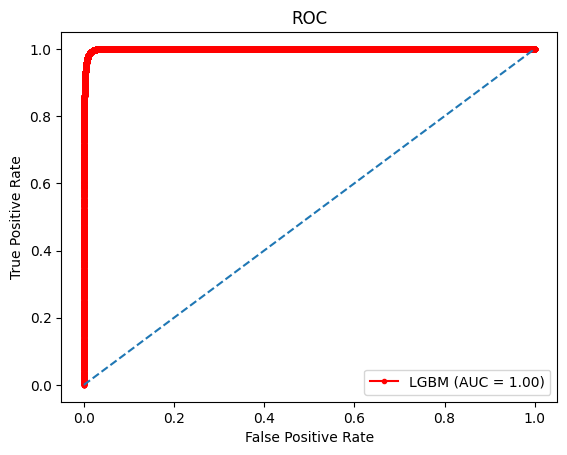

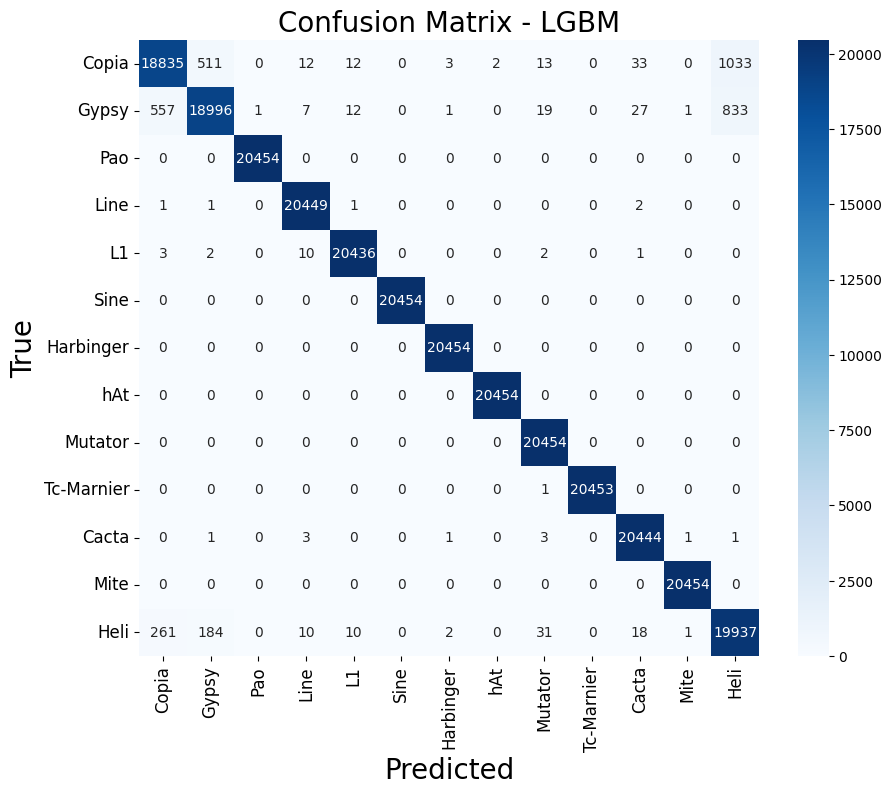

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef, roc_curve, auc
from lightgbm import LGBMClassifier

# ==============================
# Define optimized LightGBM model
# ==============================
lgbm_model = LGBMClassifier(
    n_estimators=100
)

import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef

# ==============================
# Define optimized model
# ==============================
lgbm_model = XGBClassifier(n_estimators=100)

# ==============================
# Train on ALL data (self-consistency)
# ==============================
lgbm_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = lgbm_model.predict(feature)
pred_prob = lgbm_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_lgbm = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_lgbm)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_lgbm = {}
tpr_lgbm = {}
thresh_lgbm ={}


n_class = 13

for i in range(n_class):
    fpr_lgbm[i], tpr_lgbm[i], thresh_lgbm[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_lgbm = auc(fpr_lgbm[i], tpr_lgbm[i])
roc_lgbm
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_lgbm[i], tpr_lgbm[i], marker='.', color='red',
         label='LGBM (AUC = %0.2f)' % roc_lgbm)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-lgbm_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - LGBM', fontsize=20)

# Save & show
plt.savefig('lgbm_self-test_cm.png')
plt.show()



Self-Consistency Accuracy: 99.96%

Confusion Matrix:
 [[20424    14     0     0     0     0     0     0     0     0     0     0
     16]
 [   36 20394     1     1     0     0     1     0     1     0     1     0
     19]
 [    0     1 20453     0     0     0     0     0     0     0     0     0
      0]
 [    0     0     0 20454     0     0     0     0     0     0     0     0
      0]
 [    0     1     0     2 20451     0     0     0     0     0     0     0
      0]
 [    0     0     0     0     0 20454     0     0     0     0     0     0
      0]
 [    0     0     0     0     0     0 20454     0     0     0     0     0
      0]
 [    0     0     0     0     0     0     0 20454     0     0     0     0
      0]
 [    0     0     0     0     0     0     0     0 20454     0     0     0
      0]
 [    0     0     0     0     0     0     0     0     0 20454     0     0
      0]
 [    0     0     0     0     0     0     0     0     0     0 20454     0
      0]
 [    0     0     0     0     0  

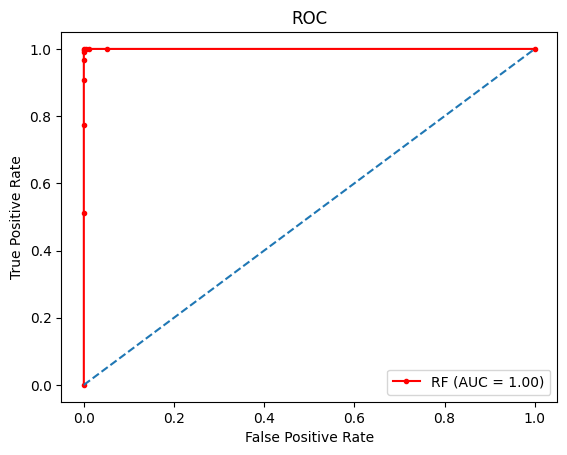

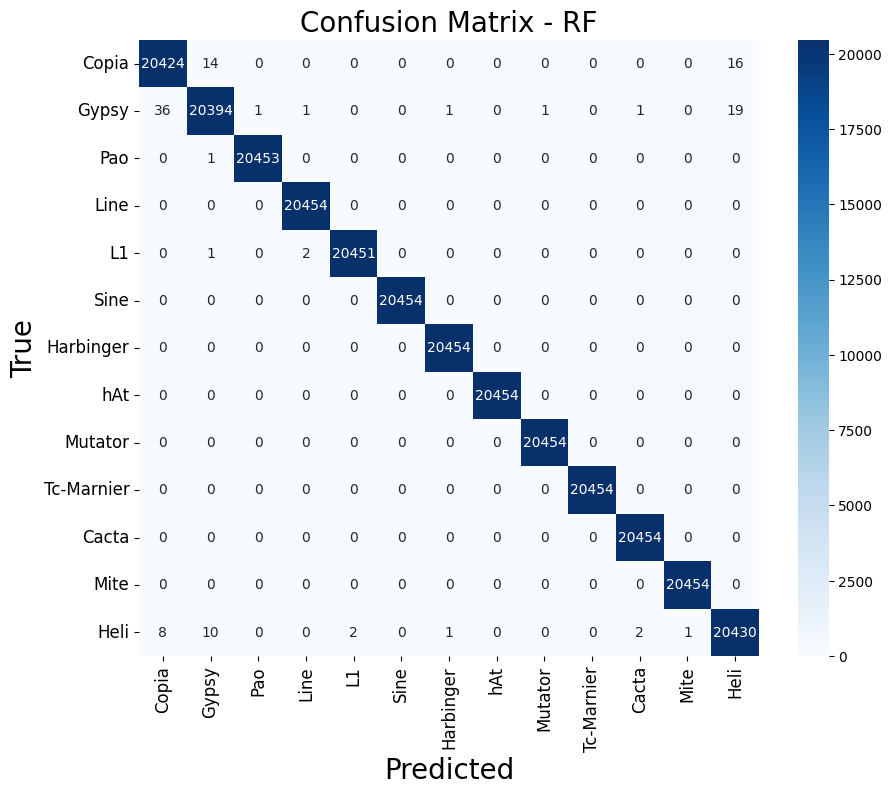

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    matthews_corrcoef, roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize

# ==============================
# Define Random Forest model
# ==============================
rf_model = RandomForestClassifier(n_estimators=10, random_state=10)
# ==============================
# Train on ALL data (self-consistency)
# ==============================
rf_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = rf_model.predict(feature)
pred_prob = rf_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_rf = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_rf)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_rf = {}
tpr_rf = {}
thresh_rf ={}


n_class = 13

for i in range(n_class):
    fpr_rf[i], tpr_rf[i], thresh_rf[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_rf = auc(fpr_rf[i], tpr_rf[i])
roc_rf
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_rf[i], tpr_rf[i], marker='.', color='red',
         label='RF (AUC = %0.2f)' % roc_rf)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-rf_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - RF', fontsize=20)

# Save & show
plt.savefig('rf_self-test_cm.png')
plt.show()



Self-Consistency Accuracy: 100.00%

Confusion Matrix:
 [[20454     0     0     0     0     0     0     0     0     0     0     0
      0]
 [    1 20453     0     0     0     0     0     0     0     0     0     0
      0]
 [    0     0 20454     0     0     0     0     0     0     0     0     0
      0]
 [    0     0     0 20454     0     0     0     0     0     0     0     0
      0]
 [    0     0     0     0 20454     0     0     0     0     0     0     0
      0]
 [    0     0     0     0     0 20454     0     0     0     0     0     0
      0]
 [    0     0     0     0     0     0 20454     0     0     0     0     0
      0]
 [    0     0     0     0     0     0     0 20454     0     0     0     0
      0]
 [    0     0     0     0     0     0     0     0 20454     0     0     0
      0]
 [    0     0     0     0     0     0     0     0     0 20454     0     0
      0]
 [    0     0     0     0     0     0     0     0     0     0 20454     0
      0]
 [    0     0     0     0     0 

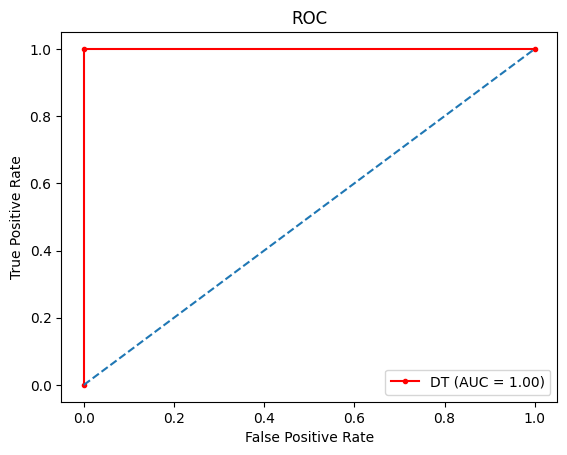

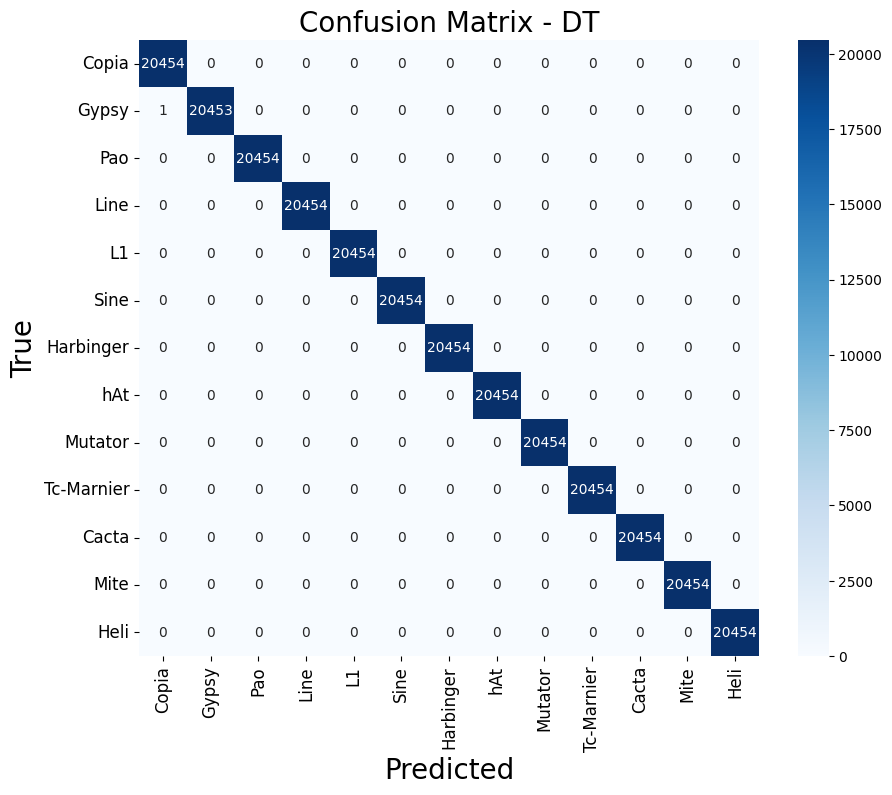

In [ ]:
 dt_model = DecisionTreeClassifier()
# train the model using X_train_dtm & y_train

# ==============================
# Train on ALL data (self-consistency)
# ==============================
dt_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = dt_model.predict(feature)
pred_prob = dt_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_dt = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_dt)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_dt = {}
tpr_dt = {}
thresh_dt ={}


n_class = 13

for i in range(n_class):
    fpr_dt[i], tpr_dt[i], thresh_dt[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_dt = auc(fpr_dt[i], tpr_dt[i])
roc_dt
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_dt[i], tpr_dt[i], marker='.', color='red',
         label='DT (AUC = %0.2f)' % roc_dt)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-dt_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - DT', fontsize=20)

# Save & show
plt.savefig('dt_self-test_cm.png')
plt.show()


# **ROC-SELF TEST**

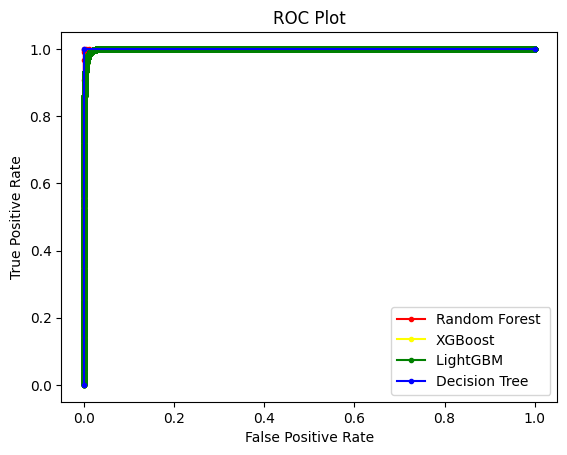

In [ ]:
import matplotlib.pyplot as plt
plt.plot(fpr_rf[i],tpr_rf[i], marker='.',color='red',label = 'Random Forest ' % roc_rf)
plt.plot(fpr_xg[i],tpr_xg[i], marker='.',color='yellow',label = 'XGBoost' % roc_xg)
plt.plot(fpr_lgbm[i],tpr_lgbm[i], marker='.',color='green',label = 'LightGBM ' % roc_lgbm)
plt.plot(fpr_dt[i],tpr_dt[i], marker='.',color='blue',label = 'Decision Tree' % roc_dt)
plt.title('ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #
plt.savefig('self-test_roc.png')
# Show plot
plt.show()


#  **Independent Set Testing (Train Test Split)**    

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, random_state=100,stratify=labels)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(186131, 521) (79771, 521)
(186131,) (79771,)


Training accuracy is 0.9898727240491911
Test accuracy is 0.9680836394178336
[[5116  390    1   27   31    1    1   10   20    0   31    4  504]
 [ 333 5201    6   21   34    0    4    0   25    4   40    7  461]
 [   1    0 6132    0    0    0    0    0    0    0    0    0    3]
 [   1    6    0 6111   11    0    1    0    1    1    3    0    2]
 [   7    9    0   29 6078    0    3    0    4    0    2    1    3]
 [   0    0    0    1    1 6134    0    0    0    0    0    0    0]
 [   0    0    0    0    1    0 6131    0    2    0    0    0    2]
 [   1    4    0    0    0    0    0 6126    3    0    0    1    1]
 [   2    2    0    0    0    0    1    0 6129    0    1    0    2]
 [   0    0    0    3    0    0    0    0    2 6129    2    0    0]
 [   0    5    0    4    0    0    2    0    7    6 6108    1    3]
 [   0    0    0    0    0    0    0    0    0    0    0 6136    0]
 [ 155  168    0   23   19    0    5    4   34    5   16   14 5694]]
              precision    recall  f1-s

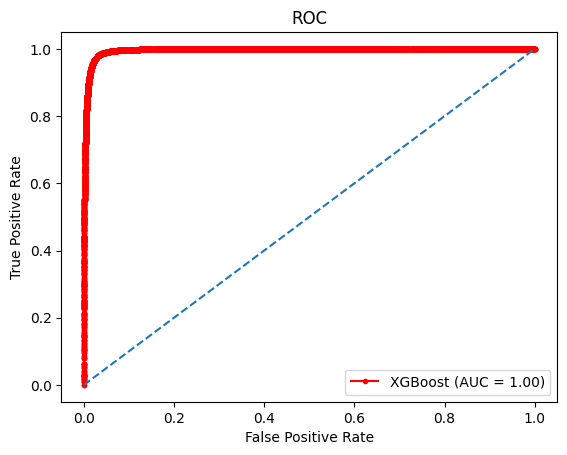

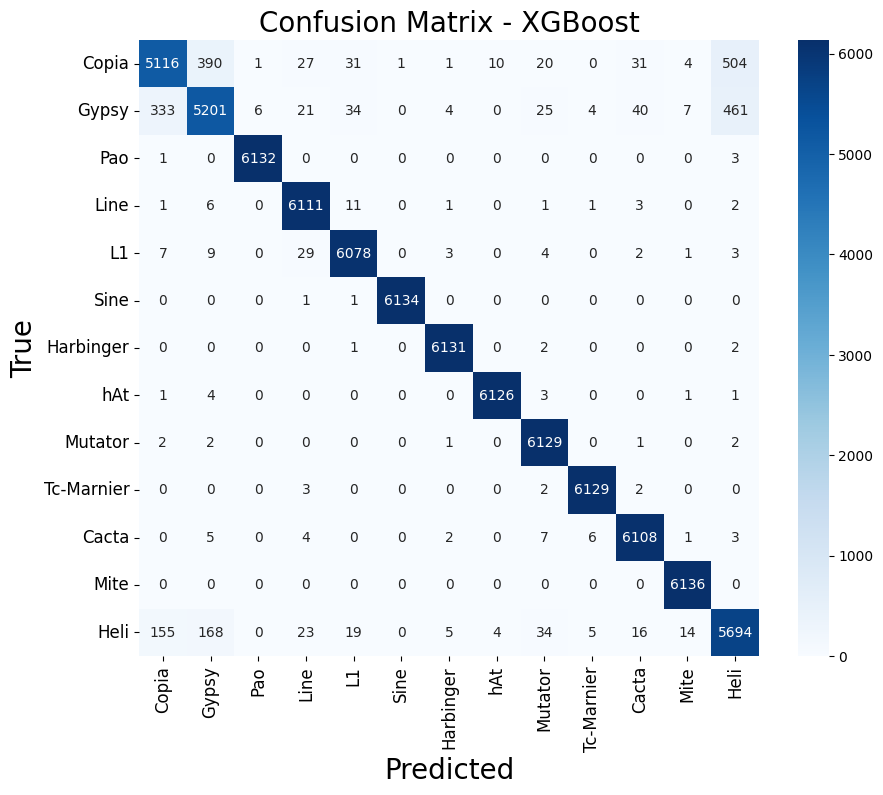

In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef
xgb1 = XGBClassifier(n_estimators=100)
xgb1.fit(X_train, y_train)
# compute the training accuracy
y_pred_train = xgb1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = xgb1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = xgb1.predict_proba(X_test)

cm_xgb1 = confusion_matrix(y_test, y_pred_test)
print(cm_xgb1)

cr_xgb1 = classification_report(y_test, y_pred_test)
print(cr_xgb1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_xgb1[0,0] / (cm_xgb1[0,0] + cm_xgb1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_xgb1[1,1] / (cm_xgb1[1,0] + cm_xgb1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_xgb1 = {}
tpr_xgb1 = {}
thresh_xgb1 = {}

n_class = 13

for i in range(n_class):
    fpr_xgb1[i], tpr_xgb1[i], thresh_xgb1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_xgb1 = auc(fpr_xgb1[i], tpr_xgb1[i])

roc_xgb1
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_xgb1[i], tpr_xgb1[i], marker='.', color='red',
         label='XGBoost (AUC = %0.2f)' % roc_xgb1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-xgb1_roc.png')
# Show plot
plt.show()



### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred_test)

## Get Class Labels
labels = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - XGBoost', fontsize=20)

# Save & show
plt.savefig('xgb1_indep-test_cm.png')
plt.show()


Training accuracy is 0.9993552927776673
Test accuracy is 0.960186032518083
[[5171  449    3   34   49    1   14    6   13    4   33    6  353]
 [ 544 4934    8   43   75    2    4    7   33    2   64   11  409]
 [  15    6 6103    0    2    0    0    0    1    0    1    0    8]
 [   3    5    2 6105    4    1    1    1    5    3    3    3    1]
 [  36   20    2   33 6033    1    1    1    2    0    0    4    3]
 [   0    0    0    0    0 6135    1    0    0    0    0    0    0]
 [   0    0    0    4    0    0 6131    1    0    0    0    0    0]
 [   2    4    0    2    4    0    0 6118    0    0    1    0    5]
 [   4    1    0    8    1    0    0    0 6118    0    3    1    1]
 [   4    4    0    4    1    3    2    0    5 6100    4    5    4]
 [   3   10    0    8    2    4    2    0    3   10 6084    1    9]
 [   0    0    0    7    1    1    4    0    3    1    1 6117    1]
 [ 220  268    2   39   28    6   14    6   25   16   24   43 5446]]
              precision    recall  f1-sc

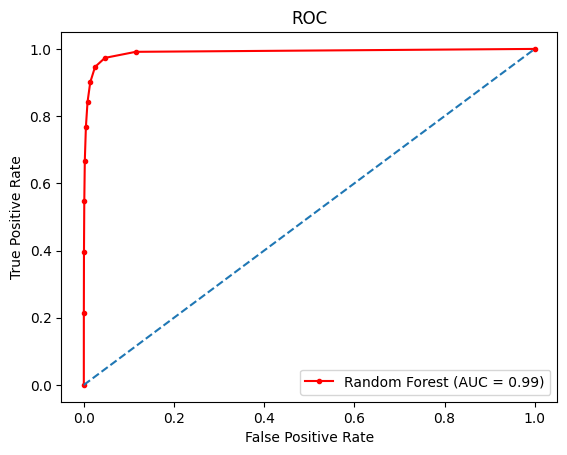

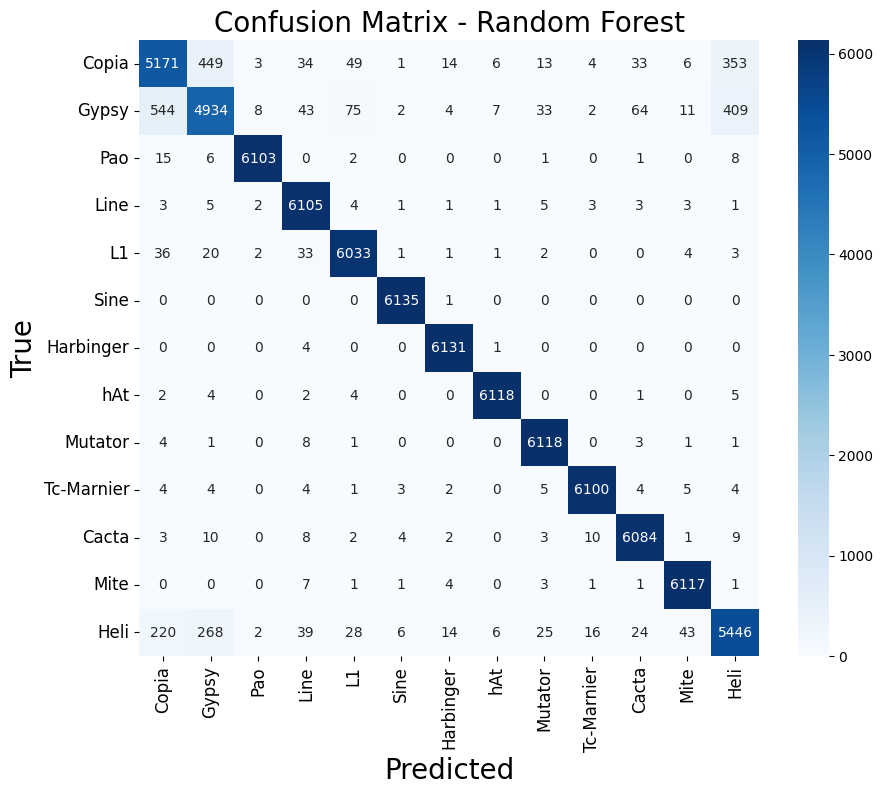

In [ ]:
rclf1 = RandomForestClassifier(n_estimators=10,random_state=10)
rclf1.fit(X_train, y_train)
rclf1.fit(X_train, y_train)
# compute the training accuracy
y_pred_train = rclf1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = rclf1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = rclf1.predict_proba(X_test)

cm_rclf1 = confusion_matrix(y_test, y_pred_test)
print(cm_rclf1)

cr_rclf1 = classification_report(y_test, y_pred_test)
print(cr_rclf1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_rclf1[0,0] / (cm_rclf1[0,0] + cm_rclf1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_rclf1[1,1] / (cm_rclf1[1,0] + cm_rclf1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_rclf1 = {}
tpr_rclf1 = {}
thresh_rclf1 = {}

n_class = 13

for i in range(n_class):
    fpr_rclf1[i], tpr_rclf1[i], thresh_rclf1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_rclf1 = auc(fpr_rclf1[i], tpr_rclf1[i])

roc_rclf1

import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_rclf1[i], tpr_rclf1[i], marker='.', color='red',
         label='Random Forest (AUC = %0.2f)' % roc_rclf1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-rclf1_roc.png')
# Show plot
plt.show()



### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

## Get Class Labels
labels = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - Random Forest', fontsize=20)

# Save & show
plt.savefig('rclf1_indep-test_cm.png')
plt.show()


Training accuracy is 0.9999946274398139
Test accuracy is 0.9134397212019405
[[4649  511   50   44  170    3   25   33   55   14   93   19  470]
 [ 628 4283   66   67  129    2   31   41  123   12  171   39  544]
 [  30   32 6033    2    5    0    0    0    5    0    4    1   24]
 [  27   54    4 5689   63   41   44   24   25   55   31   52   28]
 [  96   81    4   74 5714    8   32   15   16    9   27   20   40]
 [   2    2    0   24    4 6040    8    7   11    7    3   24    4]
 [   9    8    0   31   15   11 5962    8   26   18   12   28    8]
 [  10   16    0   13   12   11    6 6034    8    3    9    4   10]
 [  19   33    4   25   20   12   13   17 5915    4   23   40   12]
 [   7    8    2   32   18    7   17    3   11 5965    9   42   15]
 [  43   57    4   30   10    6   11   11   26   23 5851   14   50]
 [  11   17    0   57   23   39   30   17   47   37   18 5809   31]
 [ 380  412   54   55   48    1   32   37   51   20   69   56 4922]]
              precision    recall  f1-s

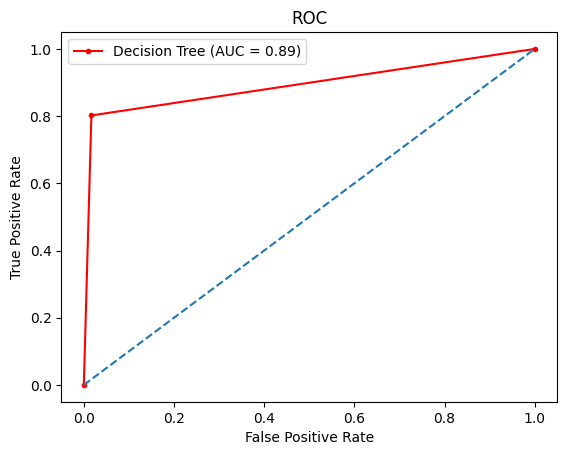

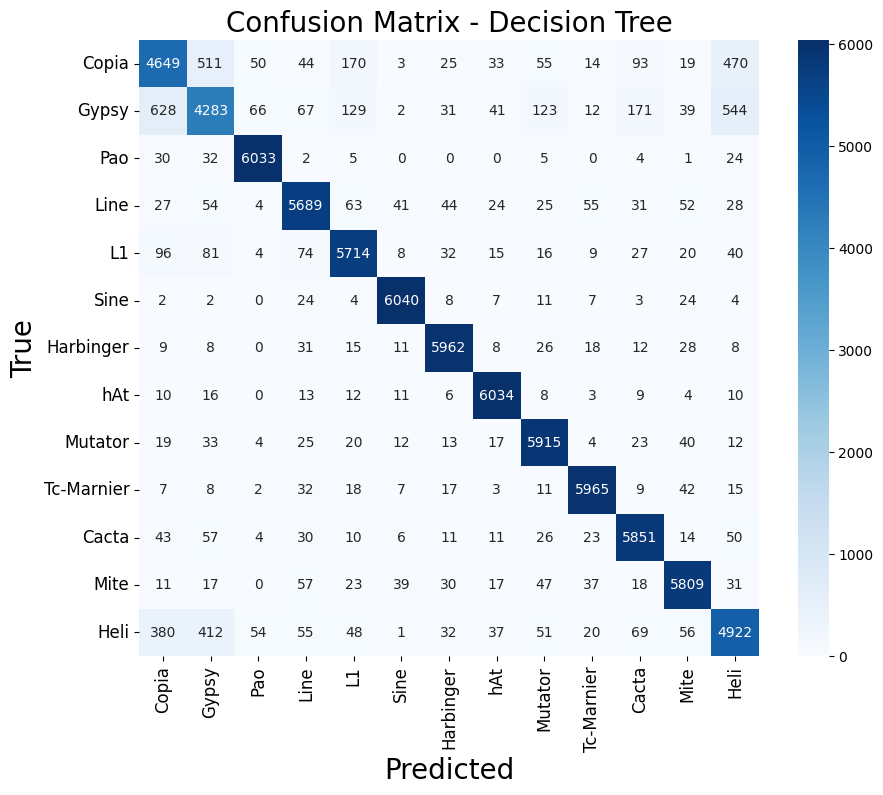

In [ ]:
dt1 = DecisionTreeClassifier()
dt1.fit(X_train, y_train)
# compute the training accuracy
y_pred_train = dt1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = dt1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = dt1.predict_proba(X_test)

cm_dt1 = confusion_matrix(y_test, y_pred_test)
print(cm_dt1)

cr_dt1 = classification_report(y_test, y_pred_test)
print(cr_dt1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_dt1[0,0] / (cm_dt1[0,0] + cm_dt1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_dt1[1,1] / (cm_dt1[1,0] + cm_dt1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_dt1 = {}
tpr_dt1 = {}
thresh_dt1 = {}

n_class = 13

for i in range(n_class):
    fpr_dt1[i], tpr_dt1[i], thresh_dt1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_dt1 = auc(fpr_dt1[i], tpr_dt1[i])

roc_dt1

import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_dt1[i], tpr_dt1[i], marker='.', color='red',
         label='Decision Tree (AUC = %0.2f)' % roc_dt1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-dt1_roc.png')
# Show plot
plt.show()



### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

## Get Class Labels
labels = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - Decision Tree', fontsize=20)

# Save & show
plt.savefig('dt1_indep-test_cm.png')
plt.show()



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.284243 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 128187
[LightGBM] [Info] Number of data points in the train set: 186131, number of used features: 516
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.565003
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.565003
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.565003
Train

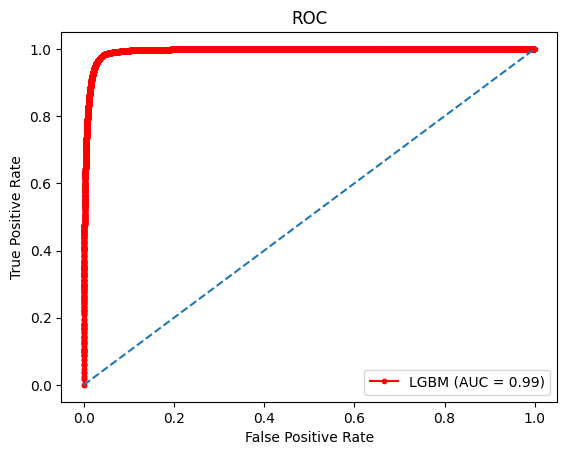

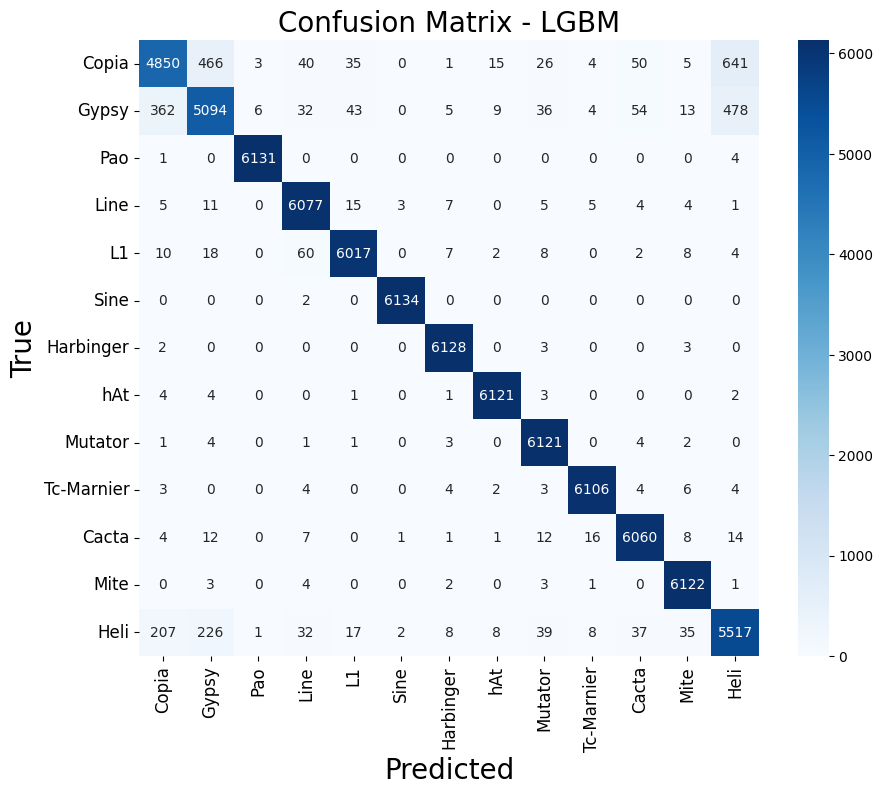

In [ ]:

from sklearn.model_selection import train_test_split, GridSearchCV
from lightgbm import LGBMClassifier

lgbm1 = LGBMClassifier(
    n_estimators=100
)

lgbm1.fit(X_train, y_train)

# compute the training accuracy
y_pred_train = lgbm1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = lgbm1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = lgbm1.predict_proba(X_test)

cm_lgbm1 = confusion_matrix(y_test, y_pred_test)
print(cm_lgbm1)

cr_lgbm1 = classification_report(y_test, y_pred_test)
print(cr_lgbm1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_lgbm1[0,0] / (cm_lgbm1[0,0] + cm_lgbm1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_lgbm1[1,1] / (cm_lgbm1[1,0] + cm_lgbm1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_lgbm1 = {}
tpr_lgbm1 = {}
thresh_lgbm1 = {}

n_class = 13

for i in range(n_class):
    fpr_lgbm1[i], tpr_lgbm1[i], thresh_lgbm1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_lgbm1 = auc(fpr_lgbm1[i], tpr_lgbm1[i])

roc_lgbm1

import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_lgbm1[i], tpr_lgbm1[i], marker='.', color='red',
         label='LGBM (AUC = %0.2f)' % roc_lgbm1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-lgbm1_roc.png')
# Show plot
plt.show()


### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

## Get Class Labels
labels = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - LGBM', fontsize=20)

# Save & show
plt.savefig('lgbm1_indep-test_cm.png')
plt.show()


**ROC-INDEPENDENT TEST**

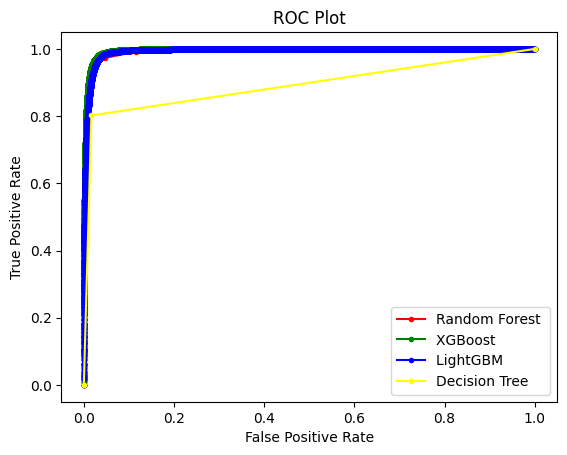

In [ ]:
import matplotlib.pyplot as plt
plt.plot(fpr_rclf1[i],tpr_rclf1[i], marker='.',color='red',label = 'Random Forest ' % roc_rclf1)
plt.plot(fpr_xgb1[i],tpr_xgb1[i], marker='.',color='green',label = 'XGBoost ' % roc_xgb1)
plt.plot(fpr_lgbm1[i],tpr_lgbm1[i], marker='.',color='blue',label = 'LightGBM ' % roc_lgbm1)
plt.plot(fpr_dt1[i],tpr_dt1[i], marker='.',color='yellow',label = 'Decision Tree ' % roc_dt1)
plt.title('ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #
plt.savefig('INDE-test_roc.png')
# Show plot
plt.show()


# **Cross Validation Test**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score,matthews_corrcoef

Mean of Accuracies:  78.17334452476334
[[10254  1902     4    28    59     5    12     0     5     5     8     7
    588]
 [ 1434 18063     3    52    69     5     6     0    13     8    17    19
    765]
 [   31    61   402     0     1     0     0     0     0     0     0     0
     14]
 [  109   148     0   781    39    23    26     2    14    40    11    35
     34]
 [  325   251     0   100   919    12    13     2     4    20     1     5
     22]
 [    5     3     0    75     6   172     4     2     3    24     0    17
      1]
 [   32    34     0    50    11    12   259     1     8    10     4    16
     18]
 [   30    36     0    39     8     5     5    68     4     6     3    11
     26]
 [   51   107     0    29     9     7    15     0   406    17    13    19
     29]
 [   14    26     0    41     8     7     8     0     4   911     1    12
     28]
 [  104   227     0    22     3     7     5     0     8     9   751     9
     43]
 [   11    47     0   108    19    31    30     

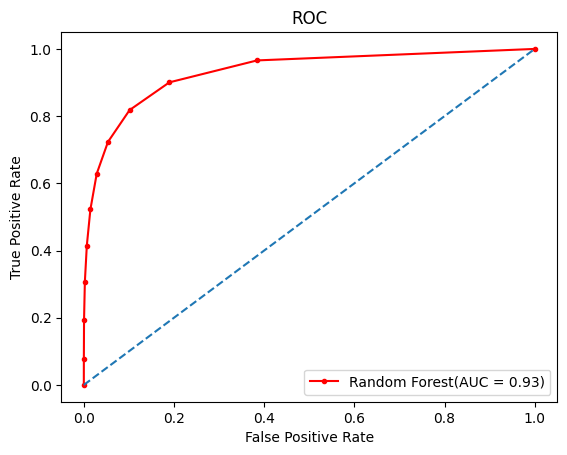

In [ ]:
rclf2 = RandomForestClassifier(n_estimators=10,random_state=10)
rclf2.fit(feature,labels)
score_rclf2 = cross_val_score(rclf2, feature , labels, cv = 10)
res=score_rclf2.mean()
print('Mean of Accuracies: ',res*100,end='\n')
pred_prob =cross_val_predict(rclf2, feature , labels, cv = 10 ,method='predict_proba')
y_pred_test = cross_val_predict(rclf2, feature , labels, cv = 10)
cm_rf1=confusion_matrix(labels,y_pred_test)
print(cm_rf1)
cr_rf1=classification_report(labels,y_pred_test)
print(cr_rf1)
print("Accuracy {0:.2f}%".format(100*accuracy_score(labels, y_pred_test)))
# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(labels, y_pred_test)
print("MCC ---> {0}".format(mcc))
sensitivity1 = cm_rf1[0,0]/(cm_rf1[0,0]+cm_rf1[0,1])
print('Sensitivity : ', sensitivity1 )

specificity1 = cm_rf1[1,1]/(cm_rf1[1,0]+cm_rf1[1,1])
print('Specificity : ', specificity1)



#AUC SCORE
fpr_rf2 = {}
tpr_rf2 = {}
thresh_rf2 ={}

n_class = 13

for i in range(n_class):
    fpr_rf2[i], tpr_rf2[i], thresh_rf2[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_rf2 = auc(fpr_rf2[i], tpr_rf2[i])
roc_rf2

import matplotlib.pyplot as plt
plt.title('ROC')
plt.plot(fpr_rf2[i], tpr_rf2[i], marker='.',color='red',label = 'Random Forest(AUC = %0.2f)' % roc_rf2)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
#Show legend
plt.legend()
plt.savefig('cross-val-test-rf_roc.png')
# Show plot
plt.show()





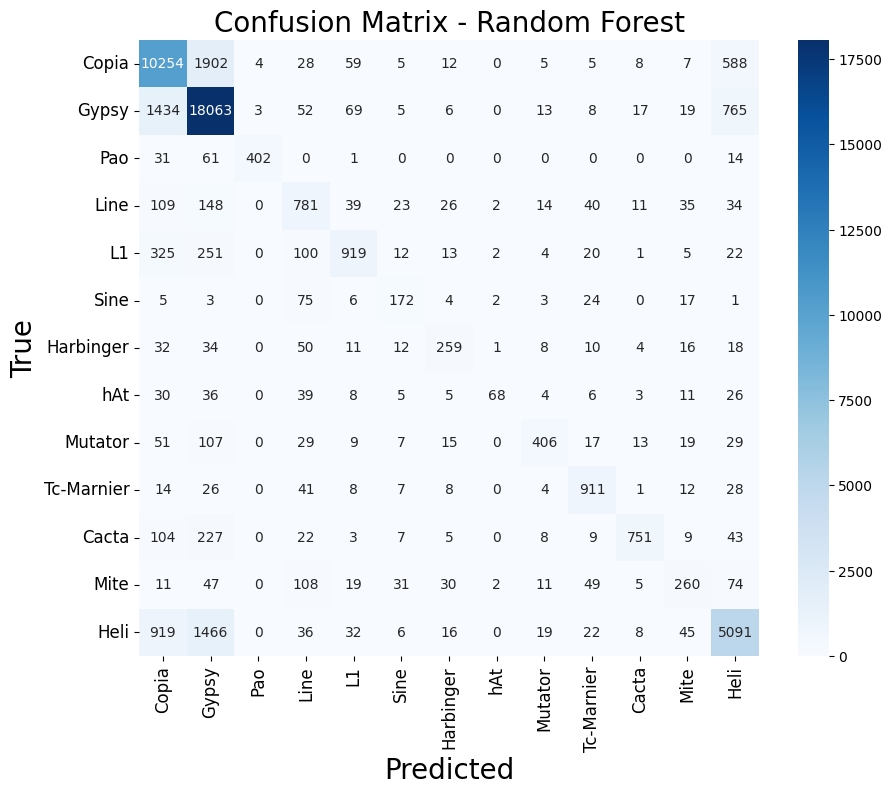

In [ ]:
### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm_rf1=confusion_matrix(labels,y_pred_test)

## Get Class Labels
label  = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']
class_names = label

### Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm_rf1, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - Random Forest', fontsize=20)

# Save & show

plt.savefig('rf_cross-val-_cm.png')
plt.show()

In [ ]:
z

In [ ]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    matthews_corrcoef, roc_curve, auc
)

# ------------------ Model ------------------
xgb2 = XGBClassifier(n_estimators=100)
xgb2.fit(feature, labels)

# Cross-validation accuracy
score_xgb2 = cross_val_score(xgb2, feature, labels, cv=10)
res = score_xgb2.mean()
print('Mean of Accuracies: ', res * 100, end='\n')

# Cross-validated predictions
pred_prob = cross_val_predict(xgb2, feature, labels, cv=10, method='predict_proba')
y_pred_test = cross_val_predict(xgb2, feature, labels, cv=10)

# ------------------ Metrics ------------------
cm_xgb2 = confusion_matrix(labels, y_pred_test)
print(cm_xgb2)

cr_xgb2 = classification_report(labels, y_pred_test)
print(cr_xgb2)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(labels, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(labels, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity
sensitivity1 = cm_xgb2[0, 0] / (cm_xgb2[0, 0] + cm_xgb2[0, 1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_xgb2[1, 1] / (cm_xgb2[1, 0] + cm_xgb2[1, 1])
print('Specificity : ', specificity1)

# ------------------ AUC SCORE ------------------
fpr_xgb2 = {}
tpr_xgb2 = {}
thresh_xgb2 = {}

n_class = 13
for i in range(n_class):
    fpr_xgb2[i], tpr_xgb2[i], thresh_xgb2[i] = roc_curve(labels, pred_prob[:, i], pos_label=i)
    roc_xgb2 = auc(fpr_xgb2[i], tpr_xgb2[i])
roc_xgb2

# ------------------ ROC Plot ------------------
plt.title('ROC')
plt.plot(fpr_xgb2[i], tpr_xgb2[i], marker='.', color='red',
         label='XGBoost (AUC = %0.2f)' % roc_xgb2)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.legend()
plt.savefig('cross-val-test-xgb2_roc.png')
plt.show()

# ------------------ Confusion Matrix Heatmap ------------------
cm_xgb2 = confusion_matrix(labels, y_pred_test)
class_names = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm_xgb2, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - XGBoost', fontsize=20)

plt.savefig('xgb2_cross-val_cm.png')
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    matthews_corrcoef, roc_curve, auc
)

# ------------------ Model ------------------
dt2 = DecisionTreeClassifier()
dt2.fit(feature, labels)

# Cross-validation accuracy
score_dt2 = cross_val_score(dt2, feature, labels, cv=10)
res = score_dt2.mean()
print('Mean of Accuracies: ', res * 100, end='\n')

# Cross-validated predictions
pred_prob = cross_val_predict(dt2, feature, labels, cv=10, method='predict_proba')
y_pred_test = cross_val_predict(dt2, feature, labels, cv=10)

# ------------------ Metrics ------------------
cm_dt2 = confusion_matrix(labels, y_pred_test)
print(cm_dt2)

cr_dt2 = classification_report(labels, y_pred_test)
print(cr_dt2)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(labels, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(labels, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity
sensitivity1 = cm_dt2[0, 0] / (cm_dt2[0, 0] + cm_dt2[0, 1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_dt2[1, 1] / (cm_dt2[1, 0] + cm_dt2[1, 1])
print('Specificity : ', specificity1)

# ------------------ AUC SCORE ------------------
fpr_dt2 = {}
tpr_dt2 = {}
thresh_dt2 = {}

n_class = 13
for i in range(n_class):
    fpr_dt2[i], tpr_dt2[i], thresh_dt2[i] = roc_curve(labels, pred_prob[:, i], pos_label=i)
    roc_dt2 = auc(fpr_dt2[i], tpr_dt2[i])
roc_dt2

# ------------------ ROC Plot ------------------
plt.title('ROC')
plt.plot(fpr_dt2[i], tpr_dt2[i], marker='.', color='red',
         label='Decision Tree (AUC = %0.2f)' % roc_dt2)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.legend()
plt.savefig('cross-val-test-dt2_roc.png')
plt.show()

# ------------------ Confusion Matrix Heatmap ------------------
cm_dt2 = confusion_matrix(labels, y_pred_test)
class_names = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm_dt2, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - Decision Tree', fontsize=20)

plt.savefig('dt2_cross-val_cm.png')
plt.show()


In [ ]:
from lightgbm import LGBMClassifier
lgbm2=LGBMClassifier(
    n_estimators=100
)
lgbm2.fit(feature, labels)

# Cross-validation accuracy
score_lgbm2 = cross_val_score(lgbm2, feature, labels, cv=10)
res = score_lgbm2.mean()
print('Mean of Accuracies: ', res * 100, end='\n')

# Cross-validated predictions
pred_prob = cross_val_predict(lgbm2, feature, labels, cv=10, method='predict_proba')
y_pred_test = cross_val_predict(lgbm2, feature, labels, cv=10)

# ------------------ Metrics ------------------
cm_lgbm2 = confusion_matrix(labels, y_pred_test)
print(cm_lgbm2)

cr_lgbm2 = classification_report(labels, y_pred_test)
print(cr_lgbm2)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(labels, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(labels, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity
sensitivity1 = cm_lgbm2[0, 0] / (cm_lgbm2[0, 0] + cm_lgbm2[0, 1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_lgbm2[1, 1] / (cm_lgbm2[1, 0] + cm_lgbm2[1, 1])
print('Specificity : ', specificity1)

# ------------------ AUC SCORE ------------------
fpr_lgbm2 = {}
tpr_lgbm2 = {}
thresh_lgbm2 = {}

n_class = 13
for i in range(n_class):
    fpr_lgbm2[i], tpr_lgbm2[i], thresh_lgbm2[i] = roc_curve(labels, pred_prob[:, i], pos_label=i)
    roc_lgbm2 = auc(fpr_lgbm2[i], tpr_lgbm2[i])
roc_lgbm2

# ------------------ ROC Plot ------------------
plt.title('ROC')
plt.plot(fpr_lgbm2[i], tpr_lgbm2[i], marker='.', color='red',
         label='LGBM (AUC = %0.2f)' % roc_lgbm2)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.legend()
plt.savefig('cross-val-test-lgbm2_roc.png')
plt.show()

# ------------------ Confusion Matrix Heatmap ------------------
cm_lgbm2 = confusion_matrix(labels, y_pred_test)
class_names = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm_lgbm2, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - LGBM', fontsize=20)

plt.savefig('lgbm2_cross-val_cm.png')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
plt.plot(fpr_rf2[i],tpr_rf2[i], marker='.',color='red',label = 'Random Forest' % roc_rf2)
plt.plot(fpr_xgb2[i],tpr_xgb2[i], marker='.',color='green',label = 'XGBoost ' % roc_xgb2)
plt.plot(fpr_lgbm2[i],tpr_lgbm2[i], marker='.',color='blue',label = 'LightGBM' % roc_lgbm2)
plt.plot(fpr_dt2[i],tpr_dt2[i], marker='.',color='yellow',label = 'Decision Tree' % roc_dt2)


plt.title('ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #q
plt.savefig('cross-val-roc.png')
# Show plot
plt.show()
